In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Dataset Paths
train_path = r"D:\Datasets\chest_xray\train"
test_path = r"D:\Datasets\chest_xray\test"
val_path = r"D:\Datasets\chest_xray\val"


In [3]:
# Image Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [4]:
# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

C:\Users\Pratik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 758ms/step - accuracy: 0.8115 - loss: 0.4141 - val_accuracy: 0.6250 - val_loss: 0.7763
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 737ms/step - accuracy: 0.8765 - loss: 0.2845 - val_accuracy: 0.8125 - val_loss: 0.4566
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 746ms/step - accuracy: 0.8871 - loss: 0.2703 - val_accuracy: 0.7500 - val_loss: 0.6684
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 726ms/step - accuracy: 0.9059 - loss: 0.2371 - val_accuracy: 0.6250 - val_loss: 0.9681
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 709ms/step - accuracy: 0.9036 - loss: 0.2404 - val_accuracy: 0.5625 - val_loss: 1.3986
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 721ms/step - accuracy: 0.9155 - loss: 0.2129 - val_accuracy: 0.7500 - val_loss: 0.7061
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 727ms/step - accuracy: 0.9248 - loss: 0.1989 - val_accuracy: 0.7500 - val_loss: 0.5711
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 730ms/step - accuracy: 0.9260 -

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.8798 - loss: 0.3516
Test Accuracy: 87.98%


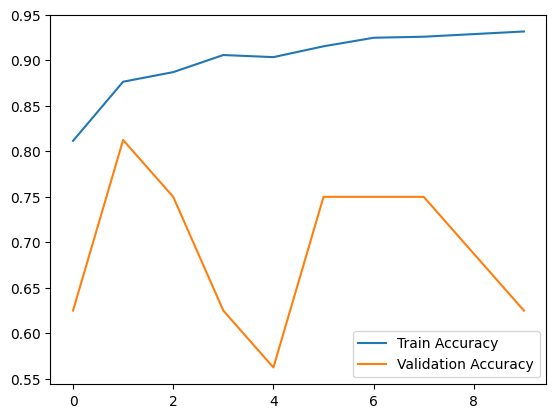

In [7]:

# Save Model
model.save("pneumonia_model.h5")

# Evaluate
test_loss, test_acc = model.evaluate(test_data)

print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [12]:
from tensorflow.keras.preprocessing import image

img_path = r"D:\Datasets\chest_xray\test\NORMAL\IM-0001-0001.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
    print("Confidence:", prediction[0][0] * 100)

else:
    print("NORMAL")
    print("Confidence:", (1 - prediction[0][0]) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
NORMAL
Confidence: 90.56303948163986


In [13]:
model.save("pneumonia_model.keras")